In [ ]:
# run before everything
%cd nn

### MNIST digits recognition

In [46]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets

%matplotlib inline 

In [3]:
import src.utils.datasets as utils

In [4]:
transform = utils.create_transform()

train_ds = utils.load_torchvision_dataset(datasets.MNIST, train=True, transform=transform)
test_ds = utils.load_torchvision_dataset(datasets.MNIST, train=False, transform=transform)

In [5]:
def show_image(data):
    img, _ = data
    img_to_plot = img.squeeze(0)
    plt.imshow(img_to_plot, cmap="gray")
    plt.axis("off")
    plt.show()


image,_ = train_ds[0]
styled_df = utils.inspect_tensor_slice(image, row_slice=slice(4, 15), col_slice=slice(4, 22),)
styled_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
1,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.976471,-0.858824,-0.858824,-0.858824,-0.011765,0.066667,0.372549,-0.796078,0.301961,1.000000
2,-1.000000,-1.000000,-1.000000,-1.000000,-0.764706,-0.717647,-0.262745,0.207843,0.333333,0.984314,0.984314,0.984314,0.984314,0.984314,0.764706,0.349020,0.984314,0.898039
3,-1.000000,-1.000000,-1.000000,-0.615686,0.866667,0.984314,0.984314,0.984314,0.984314,0.984314,0.984314,0.984314,0.984314,0.968627,-0.270588,-0.356863,-0.356863,-0.560784
4,-1.000000,-1.000000,-1.000000,-0.858824,0.717647,0.984314,0.984314,0.984314,0.984314,0.984314,0.552941,0.427451,0.937255,0.890196,-1.000000,-1.000000,-1.000000,-1.000000
5,-1.000000,-1.000000,-1.000000,-1.000000,-0.372549,0.223529,-0.160784,0.984314,0.984314,0.607843,-0.913725,-1.000000,-0.662745,0.207843,-1.000000,-1.000000,-1.000000,-1.000000
6,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.890196,-0.992157,0.207843,0.984314,-0.294118,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
7,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.090196,0.984314,0.490196,-0.984314,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
8,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.913725,0.490196,0.984314,-0.450980,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
9,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.725490,0.890196,0.764706,0.254902,-0.152941,-0.992157,-1.000000,-1.000000,-1.000000,-1.000000


In [6]:
train_6_ds = utils.filter_dataset_by_classes(train_ds, target_classes=(6,))
train_7_ds = utils.filter_dataset_by_classes(train_ds, target_classes=(7,))
len(train_6_ds),len(train_7_ds)

(5918, 6265)

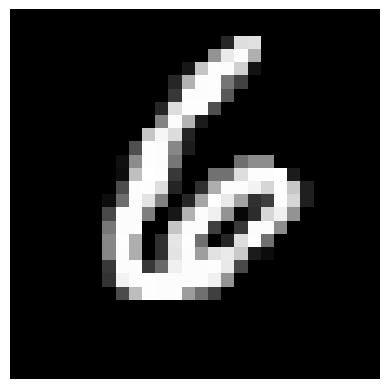

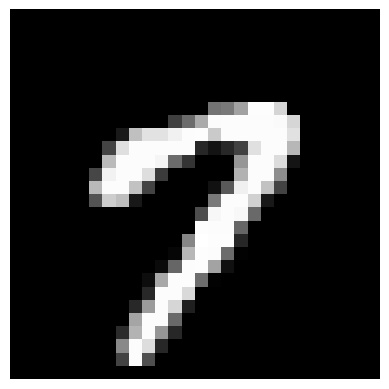

In [7]:
show_image(train_6_ds[0]); show_image(train_7_ds[0])

In [8]:
def stack_dataset_images(dataset) -> torch.Tensor:
    return torch.stack([dataset[i][0] for i in range(len(dataset))])    

stacked_sevens = stack_dataset_images(train_7_ds).float().squeeze(1) /255
stacked_sixs = stack_dataset_images(train_6_ds).float().squeeze(1) /255
stacked_sevens.shape

torch.Size([6265, 28, 28])

In [9]:
print(f"Rank: {len(stacked_sixs.shape)}", f"Dimensions: {stacked_sixs.ndim}")

Rank: 3 Dimensions: 3


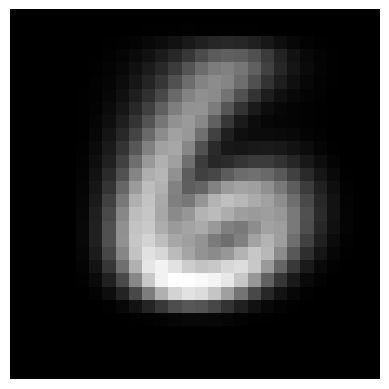

In [10]:
mean6 = stacked_sixs.mean(0)
mean7 = stacked_sevens.mean(0)
show_image((mean6, None));


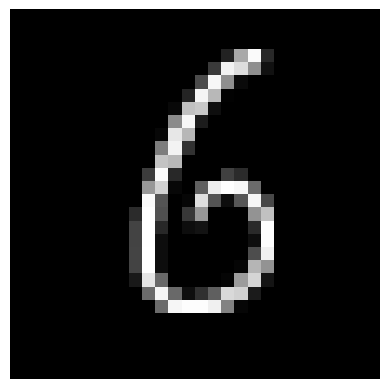

In [11]:
a = stacked_sixs[1]
show_image((a, None));

In [12]:
dist_6_abs = (a - mean6).abs().mean()
dist_6_sqr = ((a - mean6)**2).mean().sqrt()
dist_6_abs,dist_6_sqr

(tensor(0.0009), tensor(0.0017))

In [13]:
dist_7_abs = (a - mean7).abs().mean()
dist_7_sqr = ((a - mean7)**2).mean().sqrt()
dist_7_abs,dist_7_sqr

(tensor(0.0011), tensor(0.0020))

In [14]:
F.l1_loss(a.float(),mean7), F.mse_loss(a,mean7).sqrt()

(tensor(0.0011), tensor(0.0020))

In [15]:
test_6_ds = utils.filter_dataset_by_classes(test_ds, target_classes=(6,))
test_7_ds = utils.filter_dataset_by_classes(test_ds, target_classes=(7,))
len(test_6_ds),len(test_7_ds)

(958, 1028)

In [16]:
stacked_sevens_valid = stack_dataset_images(test_7_ds).float().squeeze(1) /255
stacked_sixs_valid   = stack_dataset_images(test_6_ds).float().squeeze(1) /255
stacked_sevens_valid.shape

torch.Size([1028, 28, 28])

In [17]:
def mnist_distance(a,b):
    return (a-b).abs().mean((-1,-2))

In [18]:
mnist_distance(a, mean6)

tensor(0.0009)

In [19]:
valid_3_dist = mnist_distance(stacked_sixs_valid, mean6)
valid_3_dist.shape

torch.Size([958])

In [20]:
def is_6(x): return mnist_distance(x,mean6) < mnist_distance(x,mean7)

In [21]:
is_6(a), is_6(a).float()

(tensor(True), tensor(1.))

In [22]:
accuracy_6s =      is_6(stacked_sixs_valid).float() .mean()
accuracy_7s = (1 - is_6(stacked_sevens_valid).float()).mean()

accuracy_6s,accuracy_7s,(accuracy_6s+accuracy_7s)/2

(tensor(0.9781), tensor(0.9912), tensor(0.9847))

In [23]:
train_x = torch.cat([stacked_sixs, stacked_sevens]).view(-1, 28*28)

In [24]:
train_y = torch.tensor([1]*len(train_6_ds) + [0]*len(train_7_ds)).unsqueeze(1)
train_x.shape,train_y.shape

(torch.Size([12183, 784]), torch.Size([12183, 1]))

In [25]:
dset = list(zip(train_x,train_y))
x,y = dset[0]
x.shape,y

(torch.Size([784]), tensor([1]))

In [26]:
valid_x = torch.cat([stacked_sixs_valid, stacked_sevens_valid]).view(-1, 28*28)
valid_y = torch.tensor([1]*len(test_6_ds) + [0]*len(test_7_ds)).unsqueeze(1)
valid_dset = list(zip(valid_x,valid_y))

In [27]:
def init_params(size, std=1.0): return (torch.randn(size)*std).requires_grad_()

In [28]:
weights = init_params((28*28,1))

In [29]:
bias = init_params(1)

In [30]:
(train_x[0]*weights.T).sum() + bias

tensor([0.0126], grad_fn=<AddBackward0>)

In [31]:
(train_x[2]*weights.T).sum() + bias

tensor([-0.0771], grad_fn=<AddBackward0>)

In [32]:
def linear1(xb): return xb@weights + bias
preds = linear1(train_x)
preds

tensor([[ 0.0126],
        [-0.0219],
        [-0.0771],
        ...,
        [-0.0857],
        [-0.0592],
        [-0.0962]], grad_fn=<AddBackward0>)

In [33]:
corrects = (preds>0.0).float() == train_y
corrects

tensor([[ True],
        [False],
        [False],
        ...,
        [ True],
        [ True],
        [ True]])

In [34]:
corrects.float().mean().item()

0.704177975654602

In [35]:
with torch.no_grad(): weights[0] *= 1.0001

In [36]:
preds = linear1(train_x)
((preds>0.0).float() == train_y).float().mean().item()

0.704177975654602

In [37]:
trgts  = torch.tensor([1,0,1])
prds   = torch.tensor([0.9, 0.4, 0.2])

In [38]:
def mnist_loss(predictions, targets):
    return torch.where(targets==1, 1-predictions, predictions).mean()

In [39]:
help(torch.where)

Help on built-in function where in module torch:

where(...)
    where(condition, input, other, *, out=None) -> Tensor

    Return a tensor of elements selected from either :attr:`input` or :attr:`other`, depending on :attr:`condition`.

    The operation is defined as:

    .. math::
        \text{out}_i = \begin{cases}
            \text{input}_i & \text{if } \text{condition}_i \\
            \text{other}_i & \text{otherwise} \\
        \end{cases}

    .. note::
        The tensors :attr:`condition`, :attr:`input`, :attr:`other` must be :ref:`broadcastable <broadcasting-semantics>`.

    Arguments:
        condition (BoolTensor): When True (nonzero), yield input, otherwise yield other
        input (Tensor or Scalar): value (if :attr:`input` is a scalar) or values selected at indices
                              where :attr:`condition` is ``True``
        other (Tensor or Scalar): value (if :attr:`other` is a scalar) or values selected at indices
                              where 

In [40]:
torch.where(trgts==1, 1-prds, prds)

tensor([0.1000, 0.4000, 0.8000])

In [41]:
mnist_loss(prds,trgts)

tensor(0.4333)

In [42]:
mnist_loss(torch.tensor([0.9, 0.4, 0.8]),trgts)

tensor(0.2333)

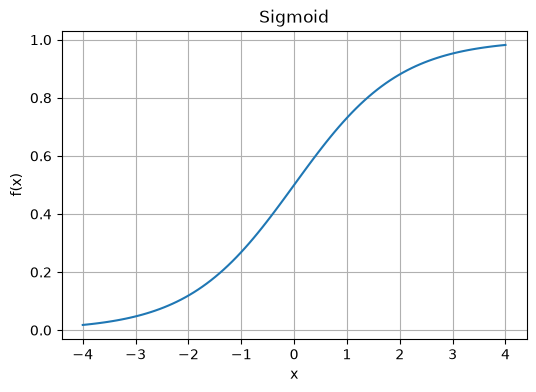

In [43]:
utils.plot_function(torch.sigmoid, title='Sigmoid', min=-4, max=4)

In [44]:
def mnist_loss(predictions, targets):
    predictions = predictions.sigmoid()
    return torch.where(targets==1, 1-predictions, predictions).mean()

In [45]:
weights = init_params((28*28,1))
bias = init_params(1)

In [49]:
from src.utils.datasets import CustomDataset

d, l = zip(*dset)
ds = CustomDataset(d, l)
dl = DataLoader(ds, batch_size=256)
xb, yb = next(iter(dl))
xb.shape,yb.shape

(torch.Size([256, 784]), torch.Size([256, 1]))

In [50]:
batch = train_x[:4]
batch.shape

torch.Size([4, 784])

In [51]:
preds = linear1(batch)
preds

tensor([[-0.0973],
        [-0.0946],
        [-0.0748],
        [-0.0218]], grad_fn=<AddBackward0>)

In [52]:
loss = mnist_loss(preds, train_y[:4])
loss

tensor(0.5180, grad_fn=<MeanBackward0>)

In [53]:
loss.backward()
weights.grad.shape,weights.grad.mean(),bias.grad

(torch.Size([784, 1]), tensor(0.0008), tensor([-0.2496]))

In [54]:
def calc_grad(xb, yb, model):
    preds = model(xb)
    loss = mnist_loss(preds, yb)
    loss.backward()

In [55]:
calc_grad(batch, train_y[:4], linear1)
weights.grad.mean(),bias.grad

(tensor(0.0015), tensor([-0.4992]))

In [56]:
calc_grad(batch, train_y[:4], linear1)
weights.grad.mean(),bias.grad

(tensor(0.0023), tensor([-0.7489]))

In [57]:
weights.grad.zero_()
bias.grad.zero_();

In [58]:
def train_epoch(model, lr, params):
    for xb,yb in dl:
        calc_grad(xb, yb, model)
        for p in params:
            p.data -= p.grad*lr
            p.grad.zero_()

In [59]:
(preds>0.0).float() == train_y[:4]

tensor([[False],
        [False],
        [False],
        [False]])

In [60]:
def batch_accuracy(xb, yb):
    preds = xb.sigmoid()
    correct = (preds>0.5) == yb
    return correct.float().mean()

In [61]:
batch_accuracy(linear1(batch), train_y[:4])

tensor(0.)

In [62]:
def validate_epoch(model, valid_dl):
    accs = [batch_accuracy(model(xb), yb) for xb,yb in valid_dl]
    return round(torch.stack(accs).mean().item(), 4)

In [68]:
validate_epoch(linear1, valid_dset)

0.5358

In [70]:
lr = 1.
params = weights,bias
train_epoch(linear1, lr, params)
validate_epoch(linear1, valid_dset)

0.5176

In [71]:
for i in range(20):
    train_epoch(linear1, lr, params)
    print(validate_epoch(linear1, valid_dset), end=' ')

0.5176 0.5176 0.5176 0.5176 0.5176 0.5176 0.5176 0.5176 0.5176 0.5176 0.5176 0.5176 0.5176 0.5176 0.5176 0.5176 0.5176 0.5176 0.5176 0.5176 